<a href="https://colab.research.google.com/github/samsuseelan/ga-unstable-approach-warning/blob/main/stable_approach_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Stable approach check
# Based on Flight Safety Foundation stabilized approach criteria

def check_approach(airspeed, target_speed, sink_rate, altitude_agl):
    warnings = []

    if airspeed > target_speed + 10:
        warnings.append("Too fast")
    if airspeed < target_speed - 5:
        warnings.append("Too slow")
    if sink_rate > 1000:
        warnings.append("Sink rate too high")

    if warnings and altitude_agl < 500:
        return "UNSTABLE: go around. " + ", ".join(warnings)
    if warnings:
        return "Caution: " + ", ".join(warnings)
    return "Stable"


print(check_approach(airspeed=68, target_speed=65, sink_rate=1200, altitude_agl=400))

UNSTABLE: go around. Sink rate too high


In [4]:
import pandas as pd

# Practice data: 2 students, 3 lessons each
approaches = pd.DataFrame({
    "student": ["Alex", "Alex", "Alex", "Priya", "Priya", "Priya"],
    "lesson": [1, 2, 3, 1, 2, 3],
    "airspeed": [80, 74, 68, 66, 79, 82],
    "target_speed": [65, 65, 65, 65, 65, 65],
    "sink_rate": [1200, 900, 700, 650, 950, 1100],
    "altitude_agl": [400, 400, 400, 400, 400, 400],
})

# Check each approach, one row at a time
results = []
for index, row in approaches.iterrows():
    result = check_approach(row["airspeed"], row["target_speed"], row["sink_rate"], row["altitude_agl"])
    results.append(result)

approaches["result"] = results
approaches

,student,lesson,airspeed,target_speed,sink_rate,altitude_agl,result
0,Alex,1,80,65,1200,400,"UNSTABLE: go around. Too fast, Sink rate too high"
1,Alex,2,74,65,900,400,Stable
2,Alex,3,68,65,700,400,Stable
3,Priya,1,66,65,650,400,Stable
4,Priya,2,79,65,950,400,UNSTABLE: go around. Too fast
5,Priya,3,82,65,1100,400,"UNSTABLE: go around. Too fast, Sink rate too high"


In [5]:
# Mark each approach as unstable (True) or not (False)
approaches["unstable"] = approaches["result"].str.startswith("UNSTABLE")

# Compare each student's first lesson with their last lesson
for student in approaches["student"].unique():
    rows = approaches[approaches["student"] == student]
    first = rows.iloc[0]["unstable"]
    last = rows.iloc[-1]["unstable"]

    if last and not first:
        print(student + ": getting worse. Review before solo.")
    elif first and not last:
        print(student + ": improving.")
    else:
        print(student + ": no change.")

Alex: improving.
Priya: getting worse. Review before solo.


In [6]:
# Download one hour of OpenSky data: Monday 27 June 2022, 15:00 UTC
!wget -q https://s3.opensky-network.org/data-samples/states/2022-06-27/15/states_2022-06-27-15.csv.tar

# Unpack the file
!tar -xf states_2022-06-27-15.csv.tar

# List the files, with sizes
!ls -lh

total 417M
-rw-r--r-- 1 root root      15K Aug 24  2017 LICENSE.txt
-rw-r--r-- 1 1001 www-data 7.0K Sep  5  2017 README.txt
drwxr-xr-x 1 root root     4.0K Sep 16 13:26 sample_data
-rw-r--r-- 1 root root     209M Jun 28  2022 states_2022-06-27-15.csv.gz
-rw-r--r-- 1 root root     209M Nov  1  2024 states_2022-06-27-15.csv.tar


In [7]:
import pandas as pd

# Columns we need
cols = ["time", "icao24", "lat", "lon", "velocity", "heading",
        "vertrate", "callsign", "onground", "baroaltitude", "geoaltitude"]

# Box around Daytona Beach airport (KDAB), about 5 miles each side
lat_min, lat_max = 29.10, 29.26
lon_min, lon_max = -81.15, -80.97

# Read the big file in pieces of 1 million rows, keep only rows inside the box
parts = []
for chunk in pd.read_csv("states_2022-06-27-15.csv.gz", usecols=cols, chunksize=1_000_000):
    near = chunk[chunk["lat"].between(lat_min, lat_max) & chunk["lon"].between(lon_min, lon_max)]
    parts.append(near)

kdab = pd.concat(parts)

print("Rows near KDAB:", len(kdab))
print("Aircraft near KDAB:", kdab["icao24"].nunique())
kdab.head()

Rows near KDAB: 1806
Aircraft near KDAB: 35


,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,baroaltitude,geoaltitude
962,1656342010,ac26ef,29.167537,-81.047920,56.204037,246.250506,0.00000,N882TC,False,274.32,304.80
1564,1656342010,aa8b0c,29.182760,-81.040488,37.047112,64.502449,3.90144,N779G,False,68.58,76.20
3347,1656342010,a61bb1,29.187788,-81.041188,38.193786,62.744672,2.60096,ERU493,False,281.94,312.42
3743,1656342010,a69920,29.134460,-81.018994,79.506151,274.825217,-2.60096,N524PS,False,3154.68,3291.84
4409,1656342010,aa168e,29.225052,-81.001828,26.482626,335.924502,0.32512,N74911,False,91.44,137.16


In [8]:
kdab = kdab.copy()

# Convert units: meters to feet, m/s to knots, m/s to feet per minute
kdab["alt_ft"] = kdab["baroaltitude"] * 3.281
kdab["speed_kt"] = kdab["velocity"] * 1.944
kdab["vs_fpm"] = kdab["vertrate"] * 196.85

# Keep airborne aircraft below 1,500 ft and slower than 140 knots
low = kdab[(kdab["alt_ft"] < 1500) & (kdab["speed_kt"] < 140) & (kdab["onground"] == False)]

# One summary line per aircraft
summary = low.groupby("callsign").agg(
    points=("time", "count"),
    lowest_ft=("alt_ft", "min"),
    avg_speed_kt=("speed_kt", "mean"),
).round(0)

print("Aircraft in the pattern:", len(summary))
summary.sort_values("points", ascending=False)

Aircraft in the pattern: 18


,points,lowest_ft,avg_speed_kt
callsign,,,
N779G,337,-25.0,76.0
N74911,218,200.0,47.0
ERU483,207,-50.0,73.0
ERU495,205,0.0,71.0
N882TC,142,-50.0,84.0
N61237,54,-25.0,70.0
ERU493,54,0.0,71.0
N1442S,53,25.0,80.0
N7115L,50,25.0,67.0


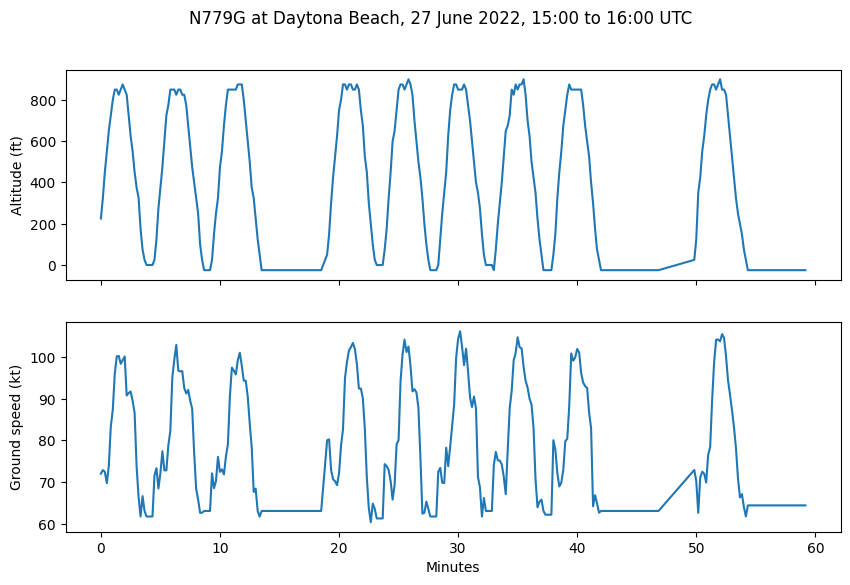

In [9]:
import matplotlib.pyplot as plt

# All reports for one aircraft, in time order
plane = kdab[kdab["callsign"].str.strip() == "N779G"].sort_values("time")

# Minutes since first report
minutes = (plane["time"] - plane["time"].min()) / 60

# Two charts, one above the other
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(minutes, plane["alt_ft"])
ax[0].set_ylabel("Altitude (ft)")
ax[1].plot(minutes, plane["speed_kt"])
ax[1].set_ylabel("Ground speed (kt)")
ax[1].set_xlabel("Minutes")
plt.suptitle("N779G at Daytona Beach, 27 June 2022, 15:00 to 16:00 UTC")
plt.show()

In [10]:
plane = plane.copy()

# A point belongs to an approach if the aircraft descends faster than 100 fpm below 700 ft
plane["descending"] = (plane["vs_fpm"] < -100) & (plane["alt_ft"] < 700)

# Give each run of descending points its own number
starts = plane["descending"] & ~plane["descending"].shift(fill_value=False)
plane["approach_id"] = starts.cumsum()

# Keep only descending points
descents = plane[plane["descending"]]

# One line per approach
approach_table = descents.groupby("approach_id").agg(
    points=("time", "count"),
    start_ft=("alt_ft", "max"),
    end_ft=("alt_ft", "min"),
    avg_gs_kt=("speed_kt", "mean"),
    max_sink_fpm=("vs_fpm", "min"),
).round(0)

# Drop very short runs, fewer than 3 points
approach_table = approach_table[approach_table["points"] >= 3]

print("Approaches found:", len(approach_table))
approach_table

Approaches found: 9


,points,start_ft,end_ft,avg_gs_kt,max_sink_fpm
approach_id,,,,,
1,12,625.0,0.0,71.0,-704.0
2,12,675.0,-25.0,72.0,-704.0
3,38,600.0,-25.0,65.0,-640.0
4,11,675.0,0.0,67.0,-832.0
5,11,600.0,-25.0,69.0,-832.0
6,11,600.0,0.0,72.0,-832.0
7,12,625.0,-25.0,70.0,-768.0
8,38,675.0,-25.0,66.0,-768.0
9,39,625.0,-25.0,67.0,-832.0


In [11]:
# Show every point in approach 3
plane[plane["approach_id"] == 3][["time", "alt_ft", "speed_kt", "vs_fpm", "onground"]]

,time,alt_ft,speed_kt,vs_fpm,onground
705773,1656342750,600.02928,90.527879,-575.998848,False
708271,1656342760,500.02440,84.066155,-639.998720,False
719184,1656342770,375.01830,78.453643,-575.998848,False
728969,1656342780,325.01586,67.629312,-575.998848,False
740766,1656342790,225.01098,68.452476,-575.998848,False
753186,1656342800,125.00610,63.076379,-447.999104,False
762578,1656342810,50.00244,61.721981,-319.999360,False
773730,1656342820,-25.00122,63.076379,-383.999232,False
775568,1656342830,-25.00122,63.076379,-383.999232,False
788019,1656342840,-25.00122,63.076379,-383.999232,False


In [12]:
# Remove frozen rows: same altitude, speed, and sink rate as the row before
plane = plane.sort_values("time")
frozen = (
    (plane["alt_ft"] == plane["alt_ft"].shift()) &
    (plane["speed_kt"] == plane["speed_kt"].shift()) &
    (plane["vs_fpm"] == plane["vs_fpm"].shift())
)
print("Frozen rows removed:", frozen.sum())
clean = plane[~frozen].copy()

# Cut approaches again on the clean data
clean["descending"] = (clean["vs_fpm"] < -100) & (clean["alt_ft"] < 700)
starts = clean["descending"] & ~clean["descending"].shift(fill_value=False)
clean["approach_id"] = starts.cumsum()
descents = clean[clean["descending"]]

approach_table = descents.groupby("approach_id").agg(
    points=("time", "count"),
    start_ft=("alt_ft", "max"),
    end_ft=("alt_ft", "min"),
    avg_gs_kt=("speed_kt", "mean"),
    max_sink_fpm=("vs_fpm", "min"),
).round(0)
approach_table = approach_table[approach_table["points"] >= 3]

print("Approaches found:", len(approach_table))
approach_table

Frozen rows removed: 105
Approaches found: 9


,points,start_ft,end_ft,avg_gs_kt,max_sink_fpm
approach_id,,,,,
1,9,625.0,0.0,73.0,-704.0
2,9,675.0,-25.0,74.0,-704.0
3,8,600.0,-25.0,72.0,-640.0
4,8,675.0,0.0,70.0,-832.0
5,8,600.0,-25.0,71.0,-832.0
6,9,600.0,0.0,73.0,-832.0
7,9,625.0,-25.0,73.0,-768.0
8,9,675.0,-25.0,75.0,-768.0
9,10,625.0,-25.0,73.0,-832.0


In [13]:
def find_approaches(df):
    """Clean one aircraft's track and cut the track into approaches."""
    df = df.sort_values("time")

    # Remove frozen rows
    frozen = (
        (df["alt_ft"] == df["alt_ft"].shift()) &
        (df["speed_kt"] == df["speed_kt"].shift()) &
        (df["vs_fpm"] == df["vs_fpm"].shift())
    )
    df = df[~frozen].copy()

    # Cut approaches
    df["descending"] = (df["vs_fpm"] < -100) & (df["alt_ft"] < 700)
    starts = df["descending"] & ~df["descending"].shift(fill_value=False)
    df["approach_id"] = starts.cumsum()
    descents = df[df["descending"]]

    table = descents.groupby("approach_id").agg(
        points=("time", "count"),
        start_ft=("alt_ft", "max"),
        end_ft=("alt_ft", "min"),
        avg_gs_kt=("speed_kt", "mean"),
        max_sink_fpm=("vs_fpm", "min"),
    ).round(0)
    return table[table["points"] >= 3]


# Run the function on every aircraft in the pattern
all_tables = []
for callsign in summary.index:
    rows = kdab[kdab["callsign"] == callsign]
    table = find_approaches(rows)
    table["callsign"] = callsign
    all_tables.append(table)

all_approaches = pd.concat(all_tables).reset_index()

print("Total approaches:", len(all_approaches))
print("Aircraft with approaches:", all_approaches["callsign"].nunique())
all_approaches

Total approaches: 36
Aircraft with approaches: 13


,approach_id,points,start_ft,end_ft,avg_gs_kt,max_sink_fpm,callsign
0,1,7,575.0,175.0,83.0,-576.0,ERU401
1,1,9,650.0,-50.0,74.0,-832.0,ERU483
2,2,10,675.0,-50.0,67.0,-960.0,ERU483
3,3,11,600.0,-25.0,69.0,-832.0,ERU483
4,4,10,625.0,-50.0,68.0,-768.0,ERU483
5,5,11,625.0,-50.0,68.0,-640.0,ERU483
6,2,8,475.0,0.0,79.0,-512.0,ERU493
7,1,7,600.0,0.0,70.0,-896.0,ERU495
8,2,7,650.0,0.0,74.0,-1216.0,ERU495
9,3,4,675.0,425.0,76.0,-1024.0,ERU495


In [14]:
# Flag approaches with a peak sink rate over 1,000 fpm
all_approaches["sink_flag"] = all_approaches["max_sink_fpm"] < -1000

# One line per aircraft
per_aircraft = all_approaches.groupby("callsign").agg(
    approaches=("approach_id", "count"),
    flagged=("sink_flag", "sum"),
    avg_gs_kt=("avg_gs_kt", "mean"),
    worst_sink_fpm=("max_sink_fpm", "min"),
).round(0)

per_aircraft.sort_values("flagged", ascending=False)

,approaches,flagged,avg_gs_kt,worst_sink_fpm
callsign,,,,
N882TC,5,4,82.0,-1344.0
ERU495,5,3,69.0,-1216.0
N108LU,1,1,81.0,-1024.0
ERU493,1,0,79.0,-512.0
ERU401,1,0,83.0,-576.0
ERU483,5,0,69.0,-960.0
N1442S,2,0,76.0,-960.0
N61237,1,0,64.0,-704.0
N42TB,1,0,108.0,-768.0


In [15]:
# Download the aircraft database for June 2022
!wget -q https://s3.opensky-network.org/data-samples/metadata/aircraft-database-complete-2022-06.csv

# Show the first 3 lines, to see the column names
!head -3 aircraft-database-complete-2022-06.csv

"","","","","","","","","","","","","","",""
"0","N798BC","","Boeing","717-200","","55169","","","","","","","Bcc Equipment Leasing Corp",""
"000000","","","","unknow","","","","","","","","","","No ADS-B Emitter Category Information"


In [17]:
# Load the database without column names, every value as text
db = pd.read_csv("aircraft-database-complete-2022-06.csv",
                                  header=None, skiprows=1, dtype=str, on_bad_lines="skip", encoding="latin-1")

print("Aircraft in database:", len(db))

# Find N779G and show every column, one per line
db[db[1] == "N779G"].T

Aircraft in database: 545584


,418061
0,aa8b0c
1,N779G
2,NaN
3,Piper
4,PA-28-181
5,NaN
6,2881222
7,NaN
8,NaN
9,NaN


In [18]:
# Keep the useful columns and give them names
aircraft = db[[0, 3, 4]].copy()
aircraft.columns = ["icao24", "manufacturer", "model"]
aircraft = aircraft.drop_duplicates("icao24")

# Link each callsign to its icao24 code, from the flight data
ids = kdab[["callsign", "icao24"]].drop_duplicates("callsign")

# Join: approaches + icao24 + aircraft type
typed = all_approaches.merge(ids, on="callsign", how="left")
typed = typed.merge(aircraft, on="icao24", how="left")

# One line per aircraft, now with type
per_type = typed.groupby(["callsign", "manufacturer", "model"], dropna=False).agg(
    approaches=("approach_id", "count"),
    flagged=("sink_flag", "sum"),
    avg_gs_kt=("avg_gs_kt", "mean"),
    worst_sink_fpm=("max_sink_fpm", "min"),
).round(0)

per_type.sort_values("flagged", ascending=False)

,,,approaches,flagged,avg_gs_kt,worst_sink_fpm
callsign,manufacturer,model,,,,
N882TC,Cessna,172S,5,4,82.0,-1344.0
ERU495,Textron Aviation Inc,172S,5,3,69.0,-1216.0
N108LU,Diamond Aircraft Ind Gmbh,DA 42,1,1,81.0,-1024.0
ERU493,Textron Aviation Inc,172S,1,0,79.0,-512.0
ERU401,Textron Aviation Inc,172S,1,0,83.0,-576.0
ERU483,Textron Aviation Inc,172S,5,0,69.0,-960.0
N1442S,Cessna,182P,2,0,76.0,-960.0
N61237,Cessna,172S,1,0,64.0,-704.0
N42TB,Raytheon Aircraft Company,58,1,0,108.0,-768.0
